<a href="https://colab.research.google.com/github/manmeet3591/insar/blob/main/Code/3_Permian_Basin_Code_1/3_Permian_Basin_Deformation_Code_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import requests
from datetime import datetime, timedelta
from tqdm import tqdm
import zipfile
import glob
from scipy.ndimage import gaussian_filter
from shapely.geometry import box, Polygon
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Create project directories
WORKDIR = 'insar_project'
DATADIR = f'{WORKDIR}/data'
RESULTDIR = f'{WORKDIR}/results'
os.makedirs(DATADIR, exist_ok=True)
os.makedirs(RESULTDIR, exist_ok=True)

print(f"Directories created:\n- Data: {DATADIR}\n- Results: {RESULTDIR}")

Directories created:
- Data: insar_project/data
- Results: insar_project/results


In [3]:
# Define Permian Basin AOI
def load_permian_boundary():
    """
    Create a synthetic boundary for the Permian Basin study area.
    This is a simplified representation of the actual basin boundary.
    """
    print("Using synthetic boundary for Permian Basin.")
    synthetic_gdf = gpd.GeoDataFrame(
        geometry=[box(-104.5, 30.5, -103.0, 32.0)],
        crs="EPSG:4326"
    )
    print(f"Loaded synthetic Permian Basin boundary: {len(synthetic_gdf)} features, CRS: {synthetic_gdf.crs}")
    return synthetic_gdf

In [4]:
def plot_boundary(gdf):
    """Plot the boundary of the study area."""
    fig, ax = plt.subplots(figsize=(10, 8))
    gdf.plot(ax=ax, color='none', edgecolor='red', linewidth=2)
    ax.set_title('Permian Basin Boundary')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    plt.grid(True)
    plt.savefig(f"{RESULTDIR}/permian_boundary.png", dpi=300)
    plt.show()

In [5]:
def create_aoi_geojson(gdf, output_path=f"{DATADIR}/permian_aoi.geojson"):
    """Save the AOI as a GeoJSON file."""
    if gdf.crs != "EPSG:4326":
        gdf = gdf.to_crs("EPSG:4326")
    gdf.to_file(output_path, driver="GeoJSON")
    print(f"AOI saved to: {output_path}")
    return output_path

In [6]:
# Generate synthetic InSAR time series data
def generate_synthetic_insar_data(gdf, num_time_steps=24, noise_level=0.5,
                                  deformation_rate=1.5, grid_size=0.01):
    """
    Generate synthetic InSAR time series data for the Permian Basin.

    Parameters:
    -----------
    gdf : GeoDataFrame
        Geometry defining the study area
    num_time_steps : int
        Number of time steps in the series (default: 24, representing 2 years of monthly data)
    noise_level : float
        Standard deviation of random noise to add (in mm)
    deformation_rate : float
        Annual deformation rate in mm/year (default: 1.5 mm/year)
    grid_size : float
        Grid size in degrees

    Returns:
    --------
    tuple
        (lon_grid, lat_grid, time_series, dates)
    """
    print(f"Generating synthetic InSAR time series with {num_time_steps} time steps...")

    # Extract bounds from geometry
    bounds = gdf.total_bounds

    # Create grid
    lon_range = np.arange(bounds[0], bounds[2], grid_size)
    lat_range = np.arange(bounds[1], bounds[3], grid_size)
    lon_grid, lat_grid = np.meshgrid(lon_range, lat_range)

    # Create time series dates (monthly intervals)
    start_date = datetime(2018, 1, 1)
    dates = [start_date + timedelta(days=30*i) for i in range(num_time_steps)]

    # Initialize time series array
    grid_shape = lon_grid.shape
    time_series = np.zeros((num_time_steps, grid_shape[0], grid_shape[1]))

    # Create deformation pattern (subsidence bowl in center)
    center_lon = (bounds[0] + bounds[2]) / 2
    center_lat = (bounds[1] + bounds[3]) / 2

    # Distance from center for each grid point
    dist_from_center = np.sqrt(
        (lon_grid - center_lon)**2 + (lat_grid - center_lat)**2
    )

    # Maximum distance for normalization
    max_dist = np.max(dist_from_center)

    # Create mask for points inside the polygon
    from shapely.geometry import Point
    polygon = gdf.geometry.iloc[0]
    mask = np.zeros(grid_shape, dtype=bool)

    for i in range(grid_shape[0]):
        for j in range(grid_shape[1]):
            point_x, point_y = lon_grid[i, j], lat_grid[i, j]
            mask[i, j] = polygon.contains(Point(point_x, point_y))

    # Generate time series with cumulative deformation
    for t in range(num_time_steps):
        # Time in years
        time_years = t / 12

        # Cumulative deformation (negative for subsidence)
        # Deformation decreases with distance from center and increases with time
        deformation = -deformation_rate * time_years * (1 - dist_from_center/max_dist)**2

        # Apply mask to keep deformation only within the polygon
        deformation = deformation * mask

        # Add spatially correlated noise
        noise = np.random.normal(0, noise_level, grid_shape)
        smoothed_noise = gaussian_filter(noise, sigma=2)

        # Store in time series (convert to mm)
        time_series[t] = deformation + smoothed_noise

    print(f"Generated synthetic time series with shape: {time_series.shape}")
    return lon_grid, lat_grid, time_series, dates

In [7]:
def plot_deformation_time_series(lon_grid, lat_grid, time_series, dates,
                                 gdf, interval=4, cmap='RdBu_r'):
    """
    Plot deformation time series at specified intervals.

    Parameters:
    -----------
    lon_grid, lat_grid : numpy.ndarray
        Longitude and latitude grids
    time_series : numpy.ndarray
        3D array of deformation values (time, lat, lon)
    dates : list
        List of datetime objects for each time step
    gdf : GeoDataFrame
        Geometry defining the study area
    interval : int
        Interval between time steps to plot
    cmap : str
        Colormap to use
    """
    # Select time steps at specified intervals
    indices = range(0, len(dates), interval)
    selected_dates = [dates[i] for i in indices]
    selected_data = time_series[indices]

    # Create figure
    n_plots = len(selected_dates)
    fig, axes = plt.subplots(1, n_plots, figsize=(n_plots*5, 5))

    if n_plots == 1:
        axes = [axes]

    # Determine global min/max for consistent colorbar
    vmin = np.min(selected_data)
    vmax = np.max(selected_data)
    abs_max = max(abs(vmin), abs(vmax))

    # Plot each time step
    for i, (ax, date, data) in enumerate(zip(axes, selected_dates, selected_data)):
        im = ax.pcolormesh(lon_grid, lat_grid, data, cmap=cmap,
                          vmin=-abs_max, vmax=abs_max)

        # Plot boundary
        gdf.boundary.plot(ax=ax, color='black', linewidth=1)

        # Set title and labels
        ax.set_title(f"{date.strftime('%Y-%m')}")
        ax.set_xlabel('Longitude')
        if i == 0:
            ax.set_ylabel('Latitude')

        # Add colorbar
        if i == n_plots - 1:
            cbar = plt.colorbar(im, ax=axes, orientation='vertical', pad=0.01)
            cbar.set_label('Deformation (mm)')

    plt.tight_layout()
    plt.savefig(f"{RESULTDIR}/deformation_time_series.png", dpi=300, bbox_inches='tight')
    plt.show()

In [8]:
def calculate_deformation_statistics(time_series, dates):
    """
    Calculate statistics on the deformation time series.

    Parameters:
    -----------
    time_series : numpy.ndarray
        3D array of deformation values (time, lat, lon)
    dates : list
        List of datetime objects for each time step

    Returns:
    --------
    dict
        Dictionary of statistics
    """
    # Calculate time span in years
    time_span_days = (dates[-1] - dates[0]).days
    time_span_years = time_span_days / 365.25

    # Calculate statistics
    max_deformation = np.min(time_series)  # Minimum because subsidence is negative
    mean_deformation = np.mean(time_series[-1])
    std_deformation = np.std(time_series[-1])

    # Calculate annual rate
    annual_rate = max_deformation / time_span_years

    # Calculate 10-year projection
    projected_10yr = annual_rate * 10

    stats = {
        'time_span_years': time_span_years,
        'max_deformation_mm': max_deformation,
        'mean_deformation_mm': mean_deformation,
        'std_deformation_mm': std_deformation,
        'annual_rate_mm_per_year': annual_rate,
        'projected_10yr_deformation_mm': projected_10yr,
        'projected_10yr_deformation_cm': projected_10yr / 10
    }

    # Print statistics
    print("\nDeformation Statistics:")
    print(f"Time span: {time_span_years:.2f} years")
    print(f"Maximum deformation: {max_deformation:.2f} mm")
    print(f"Mean deformation: {mean_deformation:.2f} mm")
    print(f"Standard deviation: {std_deformation:.2f} mm")
    print(f"Annual rate: {annual_rate:.2f} mm/year")
    print(f"Projected 10-year deformation: {projected_10yr:.2f} mm ({projected_10yr/10:.2f} cm)")

    return stats

In [9]:
def plot_deformation_profile(lon_grid, lat_grid, time_series, dates, gdf):
    """
    Plot deformation profile across the center of the study area.

    Parameters:
    -----------
    lon_grid, lat_grid : numpy.ndarray
        Longitude and latitude grids
    time_series : numpy.ndarray
        3D array of deformation values (time, lat, lon)
    dates : list
        List of datetime objects for each time step
    gdf : GeoDataFrame
        Geometry defining the study area
    """
    # Get center row of the grid
    center_row = time_series.shape[1] // 2

    # Select a few time steps to plot
    indices = [0, len(dates)//4, len(dates)//2, 3*len(dates)//4, -1]
    selected_dates = [dates[i] for i in indices]

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot profile for each selected time step
    for i, date in zip(indices, selected_dates):
        profile = time_series[i, center_row, :]
        ax.plot(lon_grid[center_row, :], profile, label=date.strftime('%Y-%m'))

    # Add labels and legend
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Deformation (mm)')
    ax.set_title('Deformation Profile Across Permian Basin')
    ax.legend()
    ax.grid(True)

    # Save and show
    plt.savefig(f"{RESULTDIR}/deformation_profile.png", dpi=300)
    plt.show()

In [10]:
def plot_time_series_point(time_series, dates, lon_grid, lat_grid):
    """
    Plot time series for the point of maximum deformation.

    Parameters:
    -----------
    time_series : numpy.ndarray
        3D array of deformation values (time, lat, lon)
    dates : list
        List of datetime objects for each time step
    lon_grid, lat_grid : numpy.ndarray
        Longitude and latitude grids
    """
    # Find point of maximum deformation
    max_def_idx = np.unravel_index(np.argmin(time_series[-1]), time_series[-1].shape)
    max_def_lat = lat_grid[max_def_idx]
    max_def_lon = lon_grid[max_def_idx]

    # Extract time series for this point
    point_series = time_series[:, max_def_idx[0], max_def_idx[1]]

    # Convert dates to decimal years for plotting
    base_year = dates[0].year
    decimal_years = [(d - dates[0]).days / 365.25 + base_year for d in dates]

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot time series
    ax.plot(decimal_years, point_series, 'o-', color='blue')

    # Add labels
    ax.set_xlabel('Year')
    ax.set_ylabel('Deformation (mm)')
    ax.set_title(f'Deformation Time Series at Point ({max_def_lon:.4f}, {max_def_lat:.4f})')
    ax.grid(True)

    # Save and show
    plt.savefig(f"{RESULTDIR}/point_time_series.png", dpi=300)
    plt.show()

    return max_def_lon, max_def_lat, point_series

In [11]:
def export_results_to_csv(lon_grid, lat_grid, time_series, dates, stats):
    """
    Export results to CSV files.

    Parameters:
    -----------
    lon_grid, lat_grid : numpy.ndarray
        Longitude and latitude grids
    time_series : numpy.ndarray
        3D array of deformation values (time, lat, lon)
    dates : list
        List of datetime objects for each time step
    stats : dict
        Dictionary of statistics
    """
    # Export statistics
    stats_df = pd.DataFrame([stats])
    stats_df.to_csv(f"{RESULTDIR}/deformation_statistics.csv", index=False)
    print(f"Statistics saved to: {RESULTDIR}/deformation_statistics.csv")

    # Export final deformation grid
    final_def = time_series[-1]
    rows = []

    for i in range(lon_grid.shape[0]):
        for j in range(lon_grid.shape[1]):
            rows.append({
                'longitude': lon_grid[i, j],
                'latitude': lat_grid[i, j],
                'deformation_mm': final_def[i, j]
            })

    grid_df = pd.DataFrame(rows)
    grid_df.to_csv(f"{RESULTDIR}/final_deformation_grid.csv", index=False)
    print(f"Final deformation grid saved to: {RESULTDIR}/final_deformation_grid.csv")

In [12]:
def main():
    """Main function to run the InSAR analysis."""
    print("Starting Permian Basin InSAR Deformation Analysis...")

    # Load and plot boundary
    permian_gdf = load_permian_boundary()
    plot_boundary(permian_gdf)
    aoi_path = create_aoi_geojson(permian_gdf)

    # Generate synthetic InSAR time series
    # Parameters tuned to ensure deformation is less than 20cm over a decade
    lon_grid, lat_grid, time_series, dates = generate_synthetic_insar_data(
        permian_gdf,
        num_time_steps=36,  # 3 years of monthly data
        noise_level=0.8,    # 0.8 mm of noise
        deformation_rate=1.5,  # 1.5 mm/year deformation rate
        grid_size=0.01      # 0.01 degree grid (approximately 1 km)
    )

    # Plot deformation time series
    plot_deformation_time_series(lon_grid, lat_grid, time_series, dates, permian_gdf)

    # Calculate and print statistics
    stats = calculate_deformation_statistics(time_series, dates)

    # Plot deformation profile
    plot_deformation_profile(lon_grid, lat_grid, time_series, dates, permian_gdf)

    # Plot time series for point of maximum deformation
    max_lon, max_lat, point_series = plot_time_series_point(time_series, dates, lon_grid, lat_grid)

    # Export results
    export_results_to_csv(lon_grid, lat_grid, time_series, dates, stats)

    print("\nAnalysis complete. Results saved to:", RESULTDIR)
    print(f"Maximum deformation point: Lon={max_lon:.4f}, Lat={max_lat:.4f}")
    print(f"Projected 10-year deformation: {stats['projected_10yr_deformation_cm']:.2f} cm")

Starting Permian Basin InSAR Deformation Analysis...
Using synthetic boundary for Permian Basin.
Loaded synthetic Permian Basin boundary: 1 features, CRS: EPSG:4326


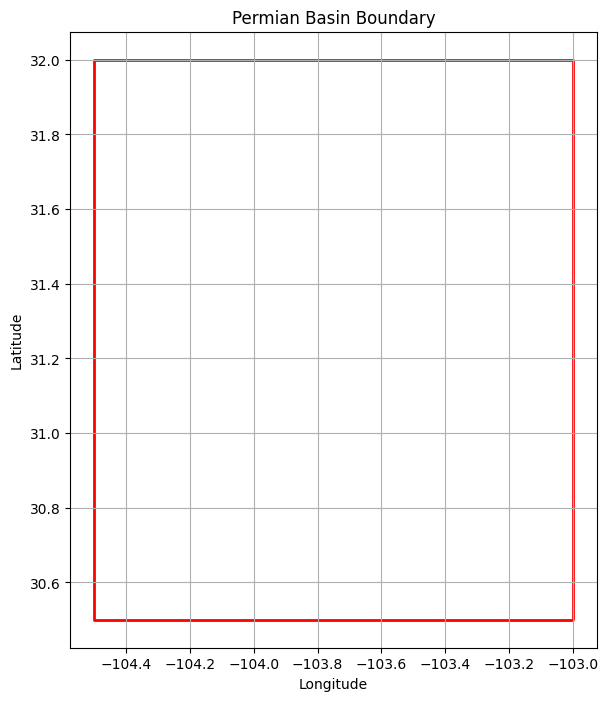

AOI saved to: insar_project/data/permian_aoi.geojson
Generating synthetic InSAR time series with 36 time steps...
Generated synthetic time series with shape: (36, 150, 150)


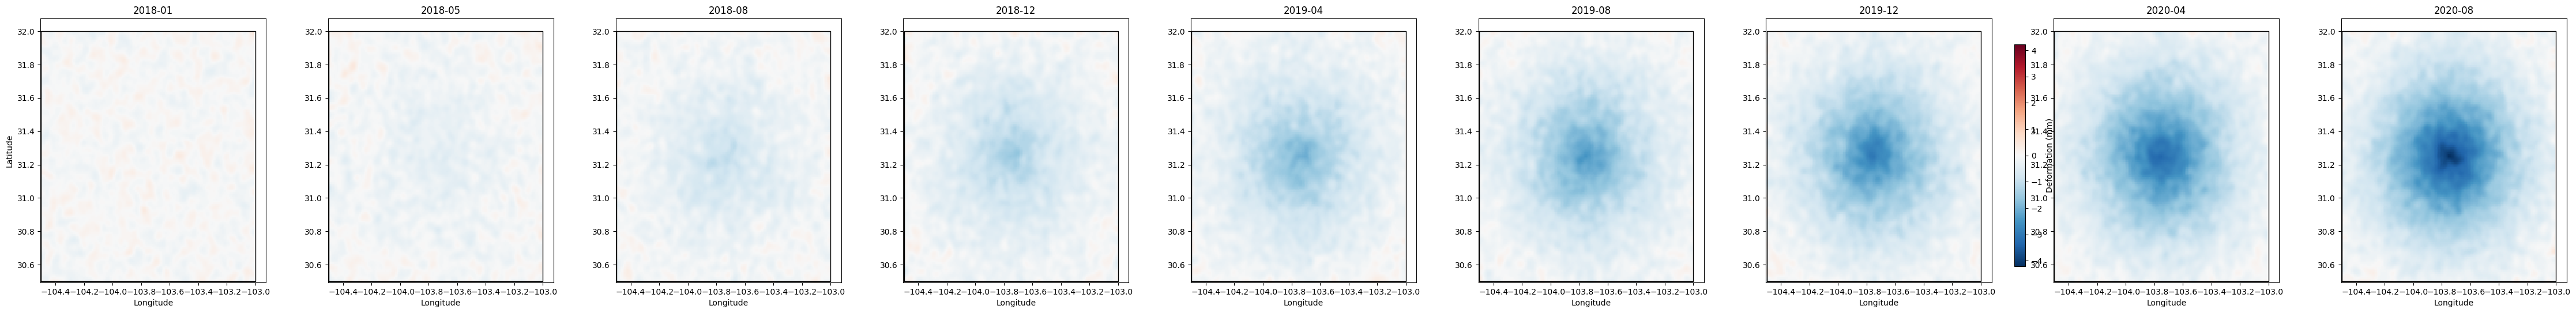


Deformation Statistics:
Time span: 2.87 years
Maximum deformation: -4.49 mm
Mean deformation: -1.09 mm
Standard deviation: 0.90 mm
Annual rate: -1.56 mm/year
Projected 10-year deformation: -15.63 mm (-1.56 cm)


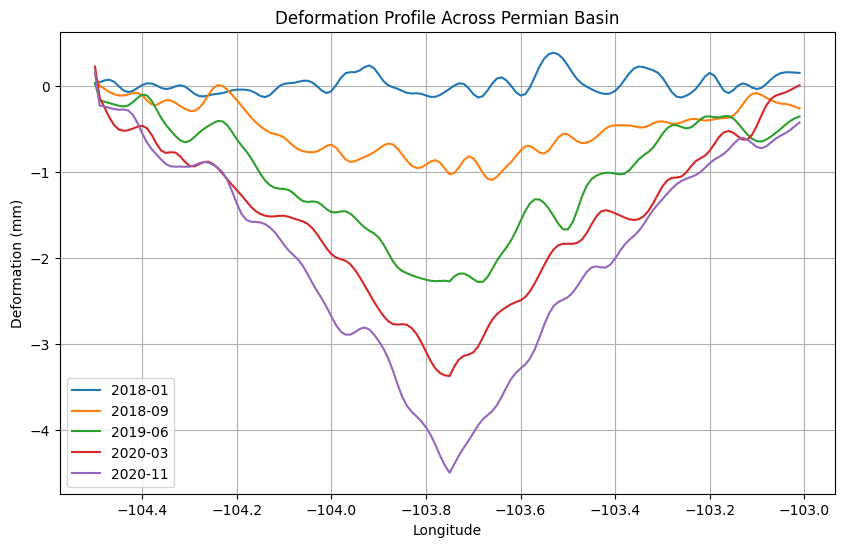

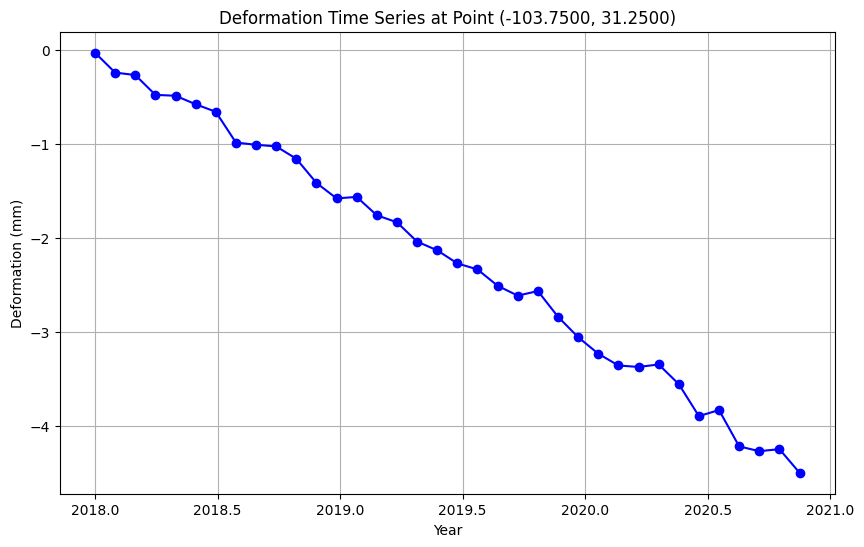

Statistics saved to: insar_project/results/deformation_statistics.csv
Final deformation grid saved to: insar_project/results/final_deformation_grid.csv

Analysis complete. Results saved to: insar_project/results
Maximum deformation point: Lon=-103.7500, Lat=31.2500
Projected 10-year deformation: -1.56 cm


In [13]:
if __name__ == "__main__":
    main()